# Anomaly Detection using Matrix Profile with PySCAMP

This notebook explores anomaly detection in time series data using the **Matrix Profile** technique, specifically implementing it with the **PySCAMP** library instead of STUMPY. 

## Overview

Matrix Profile is a powerful data structure that allows for efficient similarity search in time series data. It can be used for:
- **Anomaly Detection**: Finding unusual patterns in data
- **Motif Discovery**: Identifying repeated patterns
- **Streaming Analysis**: Real-time pattern detection

## What We'll Cover

1. 🔧 **Setup**: Install and configure PySCAMP
2. 📊 **Data Management**: Memory-efficient database loading
3. ⚙️ **Core Functions**: Time series processing utilities
4. 🧠 **Anomaly Detection**: SCAMP-based matrix profile analysis
5. 📈 **Visualization**: Interactive plots and heatmaps
6. 🌍 **Real Events**: Analysis of earthquakes, floods, and other events

## Key Advantages of PySCAMP over STUMPY

- **GPU Acceleration**: Can leverage CUDA for faster computation
- **Memory Efficiency**: Better handling of large datasets
- **Streaming Support**: Optimized for real-time applications
- **Customizable**: More control over algorithm parameters

## 1. Install and Import Required Libraries

First, we'll install the PySCAMP library and import all necessary packages. PySCAMP provides both CPU and GPU implementations of the SCAMP (Scalable Matrix Profile) algorithm.

In [1]:
# Install PySCAMP library with fallback options
import subprocess
import sys
import os

def install_pyscamp():
    """
    Try multiple methods to install PySCAMP:
    1. First try conda with conda-forge channel
    2. Fall back to pip installation
    3. If that fails, create a minimal matrix profile implementation
    """
    try:
        # Method 1: Try conda installation
        print("🔧 Attempting to install PySCAMP via conda...")
        result = subprocess.run([
            "conda", "install", "-c", "conda-forge", "pyscamp", "-y"
        ], capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            print("✅ PySCAMP installed successfully via conda!")
            return True
    except:
        pass
    
    try:
        # Method 2: Try pip installation
        print("🔧 Attempting to install PySCAMP via pip...")
        result = subprocess.run([
            sys.executable, "-m", "pip", "install", "pyscamp"
        ], capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            print("✅ PySCAMP installed successfully via pip!")
            return True
    except:
        pass
    
    print("⚠️  Could not install PySCAMP. Will create custom implementation.")
    return False

# Try to install PySCAMP
pyscamp_available = install_pyscamp()

🔧 Attempting to install PySCAMP via conda...


🔧 Attempting to install PySCAMP via pip...
⚠️  Could not install PySCAMP. Will create custom implementation.
⚠️  Could not install PySCAMP. Will create custom implementation.


In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from datetime import datetime, timedelta
from icecream import ic
from tqdm import tqdm
import arrow
from dateutil import tz
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set up Japanese timezone for our data
timezone = tz.gettz("Asia/Tokyo")

# Try to import PySCAMP or create fallback
try:
    if pyscamp_available:
        import pyscamp
        print("✅ PySCAMP imported successfully!")
        USE_PYSCAMP = True
    else:
        raise ImportError("PySCAMP not available")
except ImportError:
    print("⚠️  PySCAMP not available. Creating custom matrix profile implementation...")
    USE_PYSCAMP = False

print("📚 All libraries imported successfully!")
print(f"🔧 Using {'PySCAMP' if USE_PYSCAMP else 'Custom'} implementation")

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

⚠️  PySCAMP not available. Creating custom matrix profile implementation...
📚 All libraries imported successfully!
🔧 Using Custom implementation


## 2. Create Memory-Efficient Database Class

We'll implement a smart database class that loads data on-demand to avoid memory exhaustion. This is crucial when working with large datasets (hundreds of GB).

In [3]:
class LazyDatabase:
    """
    Memory-efficient database class that loads data on-demand.
    
    Features:
    - Intelligent caching with configurable cache size
    - Automatic memory management
    - Lazy loading to avoid memory exhaustion
    - Progress tracking for data loading operations
    
    Parameters:
    - start: Starting year for data (default: 2016)
    - stop: Ending year for data (default: 2024)
    - max_cache_size: Maximum number of years to keep in memory (default: 2)
    """
    
    def __init__(self, start=2016, stop=2024, max_cache_size=2):
        self.start = start
        self.stop = stop
        self.years = list(range(start, stop + 1))
        self._cache = {}
        self._max_cache_size = max_cache_size
        self._load_count = 0
        
        print(f"🗄️  Database initialized for years {start}-{stop}")
        print(f"📊 Total years: {len(self.years)}, Cache size: {max_cache_size}")
        
    def keys(self):
        """Return available years."""
        return self.years
    
    def _manage_cache(self, year_to_add):
        """Manage cache size by removing oldest items if necessary."""
        if len(self._cache) >= self._max_cache_size and year_to_add not in self._cache:
            # Remove oldest item
            oldest_year = min(self._cache.keys())
            print(f"🗑️  Removing year {oldest_year} from cache to free memory")
            del self._cache[oldest_year]
    
    def __getitem__(self, year):
        """Load data for specified year (with caching)."""
        if year not in self._cache:
            # Manage cache before loading new data
            self._manage_cache(year)
            
            # Load the data with progress indication
            print(f"📥 Loading year {year} data...")
            
            try:
                # Load data and areas files
                y = np.load(f"data/ntt_mss_{year}.npy")
                mids = np.load(f"data/ntt_mss_{year}_areas.npy")
                
                # Store in cache
                self._cache[year] = (y, mids)
                self._load_count += 1
                
                # Show statistics
                data_size = y.nbytes / (1024**3)  # Size in GB
                print(f"✅ Year {year}: {y.shape} data points, {data_size:.1f} GB loaded")
                
            except FileNotFoundError:
                raise FileNotFoundError(f"Data files for year {year} not found in 'data/' directory")
            except Exception as e:
                raise RuntimeError(f"Error loading data for year {year}: {str(e)}")
        
        return self._cache[year]
    
    def __contains__(self, year):
        """Check if year is available."""
        return year in self.years
    
    def get_cache_info(self):
        """Get information about current cache state."""
        cached_years = list(self._cache.keys())
        total_memory = sum(
            data[0].nbytes + data[1].nbytes 
            for data in self._cache.values()
        ) / (1024**3)  # Convert to GB
        
        return {
            'cached_years': cached_years,
            'cache_size': len(cached_years),
            'total_memory_gb': round(total_memory, 2),
            'loads_performed': self._load_count
        }

# Create database factory function
def create_lazy_database(start=2016, stop=2024, cache_size=2):
    """
    Factory function to create a LazyDatabase instance.
    
    Args:
        start: Starting year
        stop: Ending year  
        cache_size: Maximum number of years to cache
    
    Returns:
        LazyDatabase instance
    """
    return LazyDatabase(start, stop, cache_size)

print("🏗️  LazyDatabase class defined successfully!")

🏗️  LazyDatabase class defined successfully!


## 3. Define Data Joining Functions

These functions handle the extraction and combination of time series data for specific geographical mesh codes. They're essential for analyzing data at specific locations.

In [ ]:
def join_database_of_meshcode(db, meshcode):
    """
    Extract and join time series data for a specific meshcode across all years.
    Memory-efficient version that processes one year at a time.
    
    Args:
        db: Database instance (LazyDatabase)
        meshcode: Geographic mesh code identifier
        
    Returns:
        numpy.ndarray: Concatenated time series data across all years
        
    Note:
        This function preserves original data values including -1 (missing data markers)
    """
    data_parts = []
    
    print(f"🗺️  Extracting data for meshcode: {meshcode}")
    
    for year in tqdm(db.keys(), desc="Processing years"):
        try:
            year_data, meshids = db[year]
            
            # Find position of meshcode in this year's data
            pos = np.where(meshids == meshcode)[0]
            if len(pos) == 0:
                print(f"  ⚠️  Year {year}: Meshcode {meshcode} not found")
                # Create array of zeros for missing year
                if data_parts:
                    # Use length from previous year
                    yearly_series = np.zeros(len(data_parts[-1]))
                else:
                    # Default to 8760 hours (standard year)
                    yearly_series = np.zeros(8760)
            else:
                pos = pos[0]  # Take first match
                yearly_series = year_data[:, pos].copy()  # Make a copy to free memory
            
            data_parts.append(yearly_series)
            print(f"  ✅ Year {year}: {len(yearly_series)} data points extracted")
            
            # Clear year data from memory immediately after extraction
            del year_data, meshids
            
        except Exception as e:
            print(f"  ⚠️  Year {year}: {str(e)}")
            # Add zeros for failed year
            if data_parts:
                yearly_series = np.zeros(len(data_parts[-1]))
            else:
                yearly_series = np.zeros(8760)
            data_parts.append(yearly_series)
    
    # Concatenate all years
    full_series = np.concatenate(data_parts, axis=0)
    print(f"🔗 Total series length: {len(full_series)} points")
    
    # Clear intermediate data
    del data_parts
    
    return full_series

def join_database_of_meshcode_with_nan(db, meshcode):
    """
    Extract and join time series data with NaN handling for missing values.
    
    Args:
        db: Database instance (LazyDatabase)
        meshcode: Geographic mesh code identifier
        
    Returns:
        numpy.ndarray: Concatenated time series with -1 values converted to 0
        
    Note:
        This version converts -1 (missing data markers) to 0 for processing
    """
    # Get the raw data first
    data = join_database_of_meshcode(db, meshcode)
    
    if data is None:
        return None
    
    # Convert -1 to 0 (handle missing data)
    processed_data = np.where(data == -1, 0, data)
    
    missing_count = np.sum(data == -1)
    print(f"🔧 Processed {missing_count} missing values (-1 → 0)")
    
    return processed_data

def join_multiple_meshcodes(db, meshcodes, method='sum'):
    """
    Combine data from multiple meshcodes using specified aggregation method.
    Memory-efficient version that processes one meshcode at a time.
    
    Args:
        db: Database instance
        meshcodes: List of meshcode identifiers
        method: Aggregation method ('sum', 'mean', 'max', 'min')
        
    Returns:
        numpy.ndarray: Aggregated time series data
    """
    print(f"🔀 Combining {len(meshcodes)} meshcodes using '{method}' method")
    
    result_data = None
    valid_count = 0
    
    for i, meshcode in enumerate(meshcodes):
        print(f"  📍 Processing meshcode {i+1}/{len(meshcodes)}: {meshcode}")
        
        try:
            series = join_database_of_meshcode_with_nan(db, meshcode)
            if series is not None:
                if result_data is None:
                    # Initialize result array
                    result_data = series.copy()
                    if method == 'min':
                        result_data.fill(np.inf)  # Initialize for min operation
                    elif method == 'max':
                        result_data.fill(-np.inf)  # Initialize for max operation
                    elif method in ['sum', 'mean']:
                        result_data.fill(0.0)  # Initialize for sum/mean
                else:
                    # Ensure same length
                    min_len = min(len(result_data), len(series))
                    result_data = result_data[:min_len]
                    series = series[:min_len]
                    
                    # Apply aggregation method
                    if method == 'sum':
                        result_data += series
                    elif method == 'mean':
                        result_data = (result_data * valid_count + series) / (valid_count + 1)
                    elif method == 'max':
                        result_data = np.maximum(result_data, series)
                    elif method == 'min':
                        result_data = np.minimum(result_data, series)
                
                valid_count += 1
                print(f"    ✅ Added to aggregation")
                
                # Clear series from memory
                del series
            else:
                print(f"    ❌ Failed to load data")
        except Exception as e:
            print(f"    ❌ Error: {str(e)}")
            continue
    
    if result_data is None or valid_count == 0:
        print("❌ No valid meshcode data found!")
        return None
    
    # # Final processing for sum method when we have mean
    # if method == 'sum' and valid_count > 1:
    #     # No additional processing needed for sum
    #     pass
    
    print(f"✅ Combined series from {valid_count} meshcodes, length: {len(result_data)} points")
    return result_data.astype(np.float64)

print("🔧 Data joining functions defined successfully!")

🔧 Data joining functions defined successfully!


## 4. Implement Date and Time Utilities

These utility functions handle date calculations, timezone conversions, and indexing operations essential for time series analysis.

In [13]:
def get_date_one_month_ago(target_year, target_month, target_day, target_hour):
    """
    Calculate the date exactly one month before the target date.
    
    Args:
        target_year, target_month, target_day, target_hour: Target datetime components
        
    Returns:
        datetime: Date one month before the target
    """
    to_date = arrow.get(target_year, target_month, target_day, target_hour).replace(tzinfo=timezone)
    last_month = to_date.shift(months=-1)
    return last_month.datetime

def get_hours_between_dates(start_year, start_month, start_day, start_hour, 
                           stop_year, stop_month, stop_day, stop_hour):
    """
    Calculate the number of hours between two datetime points.
    
    Returns:
        int: Number of hours between start and stop dates
    """
    start = datetime(start_year, start_month, start_day, start_hour, 0, 0, 0, tzinfo=timezone)
    stop = datetime(stop_year, stop_month, stop_day, stop_hour, 0, 0, 0, tzinfo=timezone)
    delta = stop - start
    return delta.days * 24 + delta.seconds // 3600

def get_dateindex(dt, num_hours_per_year):
    """
    Convert a datetime to an index in the concatenated time series.
    
    Args:
        dt: datetime object
        num_hours_per_year: List of hours per year in the dataset
        
    Returns:
        int: Index position in the concatenated time series
    """
    # Calculate hours from start of target year
    hours_in_year = get_hours_between_dates(dt.year, 1, 1, 0, dt.year, dt.month, dt.day, dt.hour)
    
    # Add hours from previous years
    years_before = dt.year - 2016
    total_hours = sum(num_hours_per_year[:years_before]) + hours_in_year
    
    return total_hours

def get_date_from_index(index, num_hours_per_year):
    """
    Convert an index back to a datetime object.
    
    Args:
        index: Position in concatenated time series
        num_hours_per_year: List of hours per year
        
    Returns:
        datetime: Corresponding datetime object
    """
    year = 2016
    remaining_hours = index
    
    # Find the year
    for year_offset, hours_in_year in enumerate(num_hours_per_year):
        if remaining_hours < hours_in_year:
            year = 2016 + year_offset
            break
        remaining_hours -= hours_in_year
    
    # Convert remaining hours to month, day, hour
    start_of_year = datetime(year, 1, 1, 0, tzinfo=timezone)
    target_date = start_of_year + timedelta(hours=remaining_hours)
    
    return target_date

def check_end_of_year_transition(year1, year2):
    """
    Check if we're crossing a year boundary.
    
    Returns:
        bool: True if year transition occurs
    """
    return year1 != year2

def extract_datetime_components(dt):
    """
    Extract individual components from a datetime object.
    
    Returns:
        tuple: (year, month, day, hour)
    """
    return dt.year, dt.month, dt.day, dt.hour

# Date formatting utilities
def format_datetime_for_filename(dt):
    """Format datetime for use in filenames (YYYYMMDDHHMM)."""
    return dt.strftime('%Y%m%d%H%M')

def format_datetime_for_display(dt):
    """Format datetime for display (YYYY-MM-DD HH:MM)."""
    return dt.strftime('%Y-%m-%d %H:%M')

def add_hours_to_date(base_date, hours):
    """
    Add a specified number of hours to a base date.
    
    Args:
        base_date: Base datetime object
        hours: Number of hours to add
        
    Returns:
        datetime: New datetime with hours added
    """
    return base_date + timedelta(hours=hours)

def parse_datetime(datetime_str):
    """
    Parse a datetime string in format 'YYYY-MM-DD HH:MM:SS'.
    
    Args:
        datetime_str: String representation of datetime
        
    Returns:
        datetime: Parsed datetime object with timezone
    """
    # Handle different formats
    if len(datetime_str.split(' ')) == 2:
        # Format: 'YYYY-MM-DD HH:MM:SS' or 'YYYY-MM-DD HH:MM'
        dt = datetime.strptime(datetime_str, '%Y-%m-%d %H:%M' if ':' in datetime_str.split(' ')[1] and datetime_str.split(' ')[1].count(':') == 1 else '%Y-%m-%d %H:%M:%S')
    else:
        # Assume ISO format
        dt = datetime.fromisoformat(datetime_str)
    
    # Add timezone if not present
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone)
    
    return dt

print("📅 Date and time utilities defined successfully!")

📅 Date and time utilities defined successfully!


## 5. Create History Data Extraction Function

This function extracts historical data for a given time period, which serves as the baseline for anomaly detection. It handles year transitions and leap years appropriately.

In [6]:
def get_history_data(data, num_hours_per_year, current_dt, history_start_dt, 
                     cross_year_boundary, alpha=0):
    """
    Extract historical data for matrix profile calculation.
    
    This function creates a training dataset by extracting similar time periods
    from previous years, which helps establish normal patterns for anomaly detection.
    
    Args:
        data: Complete time series data
        num_hours_per_year: List of hours per year in dataset
        current_dt: Current datetime for analysis
        history_start_dt: Start of historical period (typically 1 month ago)
        cross_year_boundary: Boolean indicating year transition
        alpha: Adjustment factor for year boundary crossing
        
    Returns:
        numpy.ndarray: Historical data array for training
    """
    print(f"📚 Extracting history data from {history_start_dt} to {current_dt}")
    
    if cross_year_boundary:
        alpha = 1
        print("🔄 Year boundary crossing detected, adjusting extraction")
    
    history_segments = []
    
    # Extract data from each relevant year
    for i, year in enumerate(range(2016, history_start_dt.year + 1)):
        # Handle leap year edge case for February 29th
        if (current_dt.month == 2 and current_dt.day == 29 and 
            year % 4 != 0):
            print(f"  ⏭️  Skipping year {year} (Feb 29th in non-leap year)")
            continue
        
        try:
            # Calculate start and end indices for this year's segment
            start_dt = datetime(year, history_start_dt.month, history_start_dt.day, 
                               history_start_dt.hour, 0, 0, 0, timezone)
            end_dt = datetime(year + alpha, current_dt.month, current_dt.day, 
                             current_dt.hour, 0, 0, 0, timezone)
            
            start_index = get_dateindex(start_dt, num_hours_per_year)
            end_index = get_dateindex(end_dt, num_hours_per_year)
            
            # Extract segment
            segment = data[start_index:end_index]
            history_segments.append(segment)
            
            print(f"  📊 Year {year}: extracted {len(segment)} hours "
                  f"(indices {start_index}-{end_index})")
            
        except Exception as e:
            print(f"  ⚠️  Error extracting year {year}: {str(e)}")
            continue
    
    if not history_segments:
        raise ValueError("No historical data segments could be extracted")
    
    # Concatenate all segments
    history_data = np.concatenate(history_segments, axis=0)
    
    # Remove the last point to avoid overlap with current data
    if len(history_data) > 0:
        history_data = history_data[:-1]
    
    print(f"✅ Total history data: {len(history_data)} points from {len(history_segments)} years")
    
    return history_data

def prepare_data_for_matrix_profile(history_data, stream_point):
    """
    Prepare data for matrix profile calculation by handling missing values.
    
    Args:
        history_data: Historical baseline data
        stream_point: Current data point for analysis
        
    Returns:
        tuple: (processed_history, processed_stream_point)
    """
    print("🔧 Preparing data for matrix profile calculation...")
    
    # Convert data to float64 and handle missing values
    processed_history = np.where(history_data == -1, np.nan, history_data).astype(np.float64)
    processed_stream = np.where(stream_point == -1, np.nan, stream_point).astype(np.float64)
    
    # Count missing values
    missing_history = np.sum(np.isnan(processed_history))
    missing_stream = np.sum(np.isnan(processed_stream)) if np.isscalar(processed_stream) else 0
    
    print(f"  📊 History data: {len(processed_history)} points, {missing_history} missing")
    print(f"  📍 Stream point: {missing_stream} missing values")
    
    return processed_history, processed_stream

print("🏗️  History data extraction functions defined successfully!")

🏗️  History data extraction functions defined successfully!


## 6. Implement SCAMP-based Anomaly Detection

This is the core of our anomaly detection system. We'll implement both PySCAMP-based and custom matrix profile calculations for robust anomaly detection.

In [7]:
# Custom Matrix Profile Implementation (fallback when PySCAMP unavailable)
def custom_matrix_profile(T, m, normalize=False):
    """
    Custom implementation of matrix profile calculation.
    
    Args:
        T: Time series data
        m: Subsequence length (window size)
        normalize: Whether to normalize the data
        
    Returns:
        numpy.ndarray: Matrix profile distances
    """
    n = len(T)
    if n < m:
        raise ValueError(f"Time series length ({n}) must be >= window size ({m})")
    
    # Initialize matrix profile
    mp = np.full(n - m + 1, np.inf)
    
    print(f"🔍 Computing custom matrix profile: {n} points, window={m}")
    
    # Calculate sliding window distances
    for i in tqdm(range(n - m + 1), desc="Computing distances"):
        query = T[i:i + m]
        
        # Skip if query contains NaN
        if np.any(np.isnan(query)):
            continue
        
        # Calculate distances to all other subsequences
        for j in range(n - m + 1):
            if abs(i - j) < m:  # Skip trivial matches
                continue
                
            candidate = T[j:j + m]
            
            # Skip if candidate contains NaN
            if np.any(np.isnan(candidate)):
                continue
            
            # Calculate Euclidean distance
            distance = np.sqrt(np.sum((query - candidate) ** 2))
            
            if normalize and len(candidate) > 0:
                distance = distance / m
            
            mp[i] = min(mp[i], distance)
    
    return mp

class ScampAnomalyDetector:
    """
    Anomaly detection using SCAMP (or custom) matrix profile implementation.
    
    This class provides a unified interface for anomaly detection regardless of
    whether PySCAMP is available or we need to use custom implementation.
    """
    
    def __init__(self, window_size=3, normalize=False, threshold_method='3sigma'):
        """
        Initialize the anomaly detector.
        
        Args:
            window_size: Size of sliding window for pattern matching
            normalize: Whether to normalize matrix profile distances
            threshold_method: Method for determining anomaly threshold
        """
        self.window_size = window_size
        self.normalize = normalize
        self.threshold_method = threshold_method
        self.mp_history = []
        
        print(f"🔬 SCAMP Anomaly Detector initialized:")
        print(f"  📏 Window size: {window_size}")
        print(f"  📊 Normalize: {normalize}")
        print(f"  🎯 Threshold: {threshold_method}")
    
    def compute_matrix_profile(self, time_series):
        """
        Compute matrix profile using available method (PySCAMP or custom).
        
        Args:
            time_series: Input time series data
            
        Returns:
            numpy.ndarray: Matrix profile distances
        """
        if USE_PYSCAMP:
            return self._compute_with_pyscamp(time_series)
        else:
            return self._compute_with_custom(time_series)
    
    def _compute_with_pyscamp(self, time_series):
        """Compute matrix profile using PySCAMP."""
        try:
            print("🚀 Using PySCAMP for matrix profile calculation...")
            
            # Prepare data for PySCAMP
            T = np.array(time_series, dtype=np.float64)
            
            # Handle NaN values by interpolating
            if np.any(np.isnan(T)):
                mask = np.isnan(T)
                T[mask] = np.interp(np.flatnonzero(mask), 
                                  np.flatnonzero(~mask), T[~mask])
            
            # Compute matrix profile with PySCAMP
            mp, mpi = pyscamp.selfjoin(T, self.window_size)
            
            print(f"✅ PySCAMP computation complete: {len(mp)} profile points")
            return mp
            
        except Exception as e:
            print(f"⚠️  PySCAMP failed: {str(e)}")
            print("🔄 Falling back to custom implementation...")
            return self._compute_with_custom(time_series)
    
    def _compute_with_custom(self, time_series):
        """Compute matrix profile using custom implementation."""
        print("🛠️  Using custom matrix profile implementation...")
        return custom_matrix_profile(time_series, self.window_size, self.normalize)
    
    def calculate_threshold(self, matrix_profile):
        """
        Calculate anomaly detection threshold.
        
        Args:
            matrix_profile: Computed matrix profile
            
        Returns:
            float: Threshold value for anomaly detection
        """
        # Filter out infinite values
        valid_mp = matrix_profile[np.isfinite(matrix_profile)]
        
        if len(valid_mp) == 0:
            print("⚠️  No valid matrix profile values found!")
            return np.inf
        
        if self.threshold_method == '3sigma':
            threshold = valid_mp.mean() + 3 * valid_mp.std()
        elif self.threshold_method == '2sigma':
            threshold = valid_mp.mean() + 2 * valid_mp.std()
        elif self.threshold_method == 'percentile95':
            threshold = np.percentile(valid_mp, 95)
        elif self.threshold_method == 'percentile99':
            threshold = np.percentile(valid_mp, 99)
        else:
            threshold = valid_mp.mean() + 3 * valid_mp.std()
        
        print(f"🎯 Threshold calculated ({self.threshold_method}): {threshold:.4f}")
        print(f"   📊 MP stats: mean={valid_mp.mean():.4f}, std={valid_mp.std():.4f}")
        
        return threshold
    
    def detect_anomaly(self, data, num_hours_per_year, current_dt, stream_point, meshcode):
        """
        Main anomaly detection function.
        
        Args:
            data: Complete time series data
            num_hours_per_year: Hours per year list
            current_dt: Current datetime
            stream_point: Current data point to analyze
            meshcode: Geographic identifier
            
        Returns:
            tuple: (history_data, matrix_profile, is_anomaly, anomaly_score)
        """
        print(f"\n🔍 === ANOMALY DETECTION START ===")
        print(f"📍 Meshcode: {meshcode}")
        print(f"📅 Datetime: {format_datetime_for_display(current_dt)}")
        
        # Extract datetime components
        target_year, target_month, target_day, target_hour = extract_datetime_components(current_dt)
        
        # Get history start date (1 month ago)
        history_start = get_date_one_month_ago(target_year, target_month, target_day, target_hour)
        
        # Check for year boundary crossing
        cross_year = check_end_of_year_transition(target_year, history_start.year)
        
        # Extract historical data
        history_data = get_history_data(data, num_hours_per_year, current_dt, 
                                      history_start, cross_year)
        
        # Prepare data for matrix profile
        processed_history, processed_stream = prepare_data_for_matrix_profile(history_data, stream_point)
        
        # Compute matrix profile
        matrix_profile = self.compute_matrix_profile(processed_history)
        
        # Calculate threshold
        threshold = self.calculate_threshold(matrix_profile)
        
        # Create extended time series for anomaly scoring
        extended_series = np.append(processed_history, processed_stream)
        extended_mp = self.compute_matrix_profile(extended_series)
        
        # Get anomaly score (last value in extended matrix profile)
        if len(extended_mp) > 0:
            anomaly_score = extended_mp[-1]
            is_anomaly = anomaly_score > threshold
        else:
            anomaly_score = np.inf
            is_anomaly = True
        
        # Store for analysis
        self.mp_history.append({
            'datetime': current_dt,
            'matrix_profile': matrix_profile,
            'threshold': threshold,
            'anomaly_score': anomaly_score,
            'is_anomaly': is_anomaly
        })
        
        print(f"🎯 Anomaly score: {anomaly_score:.4f}")
        print(f"📏 Threshold: {threshold:.4f}")
        print(f"🚨 Anomaly detected: {'YES' if is_anomaly else 'NO'}")
        print(f"🔍 === ANOMALY DETECTION END ===\n")
        
        return processed_history, matrix_profile, is_anomaly, anomaly_score

# Initialize the detector
scamp_detector = ScampAnomalyDetector(window_size=3, normalize=False, threshold_method='3sigma')

print("🔬 SCAMP-based anomaly detection system ready!")

🔬 SCAMP Anomaly Detector initialized:
  📏 Window size: 3
  📊 Normalize: False
  🎯 Threshold: 3sigma
🔬 SCAMP-based anomaly detection system ready!


## 7. Load and Test Database

Now let's initialize our database and test the data loading functionality to ensure everything works correctly.

In [8]:
# Initialize the lazy database
print("🚀 Initializing database...")
db = create_lazy_database(start=2016, stop=2024, cache_size=2)

print(f"\n📋 Database Information:")
print(f"  🗓️  Years available: {db.years}")
print(f"  💾 Cache size: {db._max_cache_size} years")
print(f"  🔢 Total years: {len(db.years)}")

# Test database access
print(f"\n🧪 Testing database access...")

# Test accessing a single year
test_year = 2021
print(f"📊 Testing access to year {test_year}...")
test_data = db[test_year]
data_shape = test_data[0].shape
areas_shape = test_data[1].shape

print(f"✅ Year {test_year} data loaded successfully:")
print(f"  📈 Data shape: {data_shape}")
print(f"  🗺️  Areas shape: {areas_shape}")
print(f"  💽 Data size: {test_data[0].nbytes / (1024**3):.1f} GB")

# Show cache information
cache_info = db.get_cache_info()
print(f"\n📊 Cache Status:")
print(f"  🗂️  Cached years: {cache_info['cached_years']}")
print(f"  💾 Memory usage: {cache_info['total_memory_gb']} GB")
print(f"  🔄 Loads performed: {cache_info['loads_performed']}")

# Test accessing another year to see cache management
print(f"\n🔄 Testing cache management by accessing year 2020...")
test_data_2020 = db[2020]

# Show updated cache information
cache_info = db.get_cache_info()
print(f"\n📊 Updated Cache Status:")
print(f"  🗂️  Cached years: {cache_info['cached_years']}")
print(f"  💾 Memory usage: {cache_info['total_memory_gb']} GB")
print(f"  🔄 Loads performed: {cache_info['loads_performed']}")

# Prepare metadata for analysis
num_hours_per_year = [db[year][0].shape[0] for year in db.keys()]
print(f"\n📅 Hours per year: {num_hours_per_year}")
print(f"📊 Total hours in dataset: {sum(num_hours_per_year)}")

print("\n✅ Database initialization and testing complete!")

🚀 Initializing database...
🗄️  Database initialized for years 2016-2024
📊 Total years: 9, Cache size: 2

📋 Database Information:
  🗓️  Years available: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  💾 Cache size: 2 years
  🔢 Total years: 9

🧪 Testing database access...
📊 Testing access to year 2021...
📥 Loading year 2021 data...


✅ Year 2021: (8760, 1436131) data points, 46.9 GB loaded
✅ Year 2021 data loaded successfully:
  📈 Data shape: (8760, 1436131)
  🗺️  Areas shape: (1436131,)
  💽 Data size: 46.9 GB

📊 Cache Status:
  🗂️  Cached years: [2021]
  💾 Memory usage: 46.87 GB
  🔄 Loads performed: 1

🔄 Testing cache management by accessing year 2020...
📥 Loading year 2020 data...
✅ Year 2020: (8784, 1420193) data points, 46.5 GB loaded

📊 Updated Cache Status:
  🗂️  Cached years: [2021, 2020]
  💾 Memory usage: 93.35 GB
  🔄 Loads performed: 2
🗑️  Removing year 2020 from cache to free memory
📥 Loading year 2016 data...
✅ Year 2020: (8784, 1420193) data points, 46.5 GB loaded

📊 Updated Cache Status:
  🗂️  Cached years: [2021, 2020]
  💾 Memory usage: 93.35 GB
  🔄 Loads performed: 2
🗑️  Removing year 2020 from cache to free memory
📥 Loading year 2016 data...
✅ Year 2016: (8784, 1421845) data points, 46.5 GB loaded
🗑️  Removing year 2016 from cache to free memory
📥 Loading year 2017 data...
✅ Year 2016: (8784, 142184

## 8. Configure Event Parameters

Let's set up event configurations for various real-world events including earthquakes, floods, and other significant occurrences. Each event has specific parameters for analysis.

In [14]:
# Event configuration dictionary
event_configs = {
    'noto_earthquake': {
        'name': 'Noto Peninsula Earthquake (Mw7.5)',
        'datetime': datetime(2024, 1, 1, 16, 0, 0, 0, timezone),
        'main_meshcode': 563712214,
        'meshcodes': [563712311, 563712312, 563712321,
                     563712213, 563712214, 563712223,
                     563712211],
        'center_index': 4,  # Position of main meshcode in list
        'merge_data': True,
        'description': '7.5 magnitude earthquake that struck Noto Peninsula on New Year\'s Day'
    },
    
    'haneda_collision': {
        'name': 'Haneda Airport Runway Collision',
        'datetime': datetime(2024, 1, 2, 17, 0, 0, 0, timezone),
        'main_meshcode': 533937621,
        'meshcodes': [533937614, 533937623, 533937624,
                     533937612, 533937621, 533937622,
                     533937514, 533937523, 533937524],
        'center_index': 4,
        'merge_data': True,
        'description': 'Aircraft collision at Haneda Airport involving JAL516 and Coast Guard aircraft'
    },
    
    'kurashiki_flood': {
        'name': 'Kurashiki Flood',
        'datetime': datetime(2018, 7, 7, 1, 0, 0, 0, timezone),
        'main_meshcode': 513375542,
        'meshcodes': [513375542],  # Single meshcode for this event
        'center_index': 0,
        'merge_data': False,
        'description': 'Severe flooding in Kurashiki during July 2018 heavy rains'
    },
    
    'fukushima_earthquake': {
        'name': 'Fukushima Earthquake (March 2022)',
        'datetime': datetime(2022, 3, 16, 23, 0, 0, 0, timezone),
        'main_meshcode': 574007333,
        'meshcodes': [574007433, 574007434,
                     574007431, 574007432,
                     574007333, 574007334],
        'center_index': 4,
        'merge_data': True,
        'description': 'M7.4 earthquake off Fukushima Prefecture'
    },
    
    'taylor_swift_concert': {
        'name': 'Taylor Swift – The Eras Tour (Tokyo Dome)',
        'datetime': datetime(2024, 2, 7, 18, 0, 0, 0, timezone),
        'main_meshcode': 533946403,
        'meshcodes': [533945592, 533946501, 533946502,
                     533945494, 533946403, 533946404,
                     533945492, 533946401, 533946402],
        'center_index': 4,
        'merge_data': True,
        'description': 'Taylor Swift concert at Tokyo Dome with massive crowd movement'
    }
}

# Select event for analysis
selected_event = 'noto_earthquake'  # Change this to analyze different events

# Extract event parameters
event = event_configs[selected_event]
event_dt = event['datetime']
meshcode = event['main_meshcode']
meshcodes = event['meshcodes']
event_name = event['name']
merge = event['merge_data']
order = event['center_index']

print(f"🎯 Selected Event: {event_name}")
print(f"📅 Date & Time: {format_datetime_for_display(event_dt)}")
print(f"📍 Main Meshcode: {meshcode}")
print(f"🗺️  Total Meshcodes: {len(meshcodes)}")
print(f"🔗 Merge Data: {merge}")
print(f"📝 Description: {event['description']}")

# Create visualization titles and filenames
if merge and len(meshcodes) > 1:
    title = f"Level {order} - {meshcodes[order]} Merged, Date: {format_datetime_for_display(event_dt)}, {event_name}"
    filename = f"pyscamp_{event_name.replace(' ', '').replace('(', '').replace(')', '')}_{meshcodes[order]}_merged_{format_datetime_for_filename(event_dt)}"
else:
    title = f"Meshcode: {meshcode}, Date: {format_datetime_for_display(event_dt)}, {event_name}"
    filename = f"pyscamp_{event_name.replace(' ', '').replace('(', '').replace(')', '')}_{meshcode}_{format_datetime_for_filename(event_dt)}"

print(f"\n📊 Analysis Configuration:")
print(f"  📈 Title: {title}")
print(f"  💾 Filename: {filename}")

# Global analysis parameters
start_date = datetime(2016, 1, 1, 0, tzinfo=timezone)  # Dataset start date

print(f"\n✅ Event configuration complete!")
print(f"📅 Dataset start date: {format_datetime_for_display(start_date)}")

🎯 Selected Event: Noto Peninsula Earthquake (Mw7.5)
📅 Date & Time: 2024-01-01 16:00
📍 Main Meshcode: 563712214
🗺️  Total Meshcodes: 7
🔗 Merge Data: True
📝 Description: 7.5 magnitude earthquake that struck Noto Peninsula on New Year's Day

📊 Analysis Configuration:
  📈 Title: Level 4 - 563712214 Merged, Date: 2024-01-01 16:00, Noto Peninsula Earthquake (Mw7.5)
  💾 Filename: pyscamp_NotoPeninsulaEarthquakeMw7.5_563712214_merged_202401011600

✅ Event configuration complete!
📅 Dataset start date: 2016-01-01 00:00


In [10]:
# Extract and prepare time series data for the selected event
print(f"🔍 Extracting time series data for {event_name}...")

if merge and len(meshcodes) > 1:
    print(f"🔗 Merging data from {len(meshcodes)} meshcodes...")
    data = join_multiple_meshcodes(db, meshcodes, method='sum')
else:
    print(f"📍 Extracting data for single meshcode: {meshcode}")
    data = join_database_of_meshcode_with_nan(db, meshcode)

if data is None:
    raise ValueError(f"Failed to extract data for event: {event_name}")

# Convert to proper format
data = np.where(data == -1, np.nan, data).astype(np.float64)

print(f"✅ Data extraction complete:")
print(f"  📊 Series length: {len(data)} points")
print(f"  📅 Time span: {len(data) / 24 / 365.25:.1f} years")
print(f"  🔍 NaN values: {np.sum(np.isnan(data))}")
print(f"  📈 Value range: {np.nanmin(data):.2f} to {np.nanmax(data):.2f}")

# Prepare metadata
num_hours_per_year = [db[key][0].shape[0] for key in db.keys()]

print(f"\n📋 Metadata prepared for analysis")

🔍 Extracting time series data for Noto Peninsula Earthquake (Mw7.5)...
🔗 Merging data from 7 meshcodes...
🔀 Combining 7 meshcodes using 'sum' method
  📍 Processing meshcode 1/7: 563712311
🗺️  Extracting data for meshcode: 563712311


Processing years:   0%|          | 0/9 [00:00<?, ?it/s]

🗑️  Removing year 2023 from cache to free memory
📥 Loading year 2016 data...


Processing years:  11%|█         | 1/9 [00:15<02:05, 15.70s/it]

✅ Year 2016: (8784, 1421845) data points, 46.5 GB loaded
  ✅ Year 2016: 8784 data points extracted
🗑️  Removing year 2016 from cache to free memory
📥 Loading year 2017 data...


...

Processing years:  78%|███████▊  | 7/9 [02:01<00:34, 17.26s/it]

✅ Year 2022: (8760, 1434557) data points, 46.8 GB loaded
  ✅ Year 2022: 8760 data points extracted
🗑️  Removing year 2022 from cache to free memory
📥 Loading year 2023 data...


Processing years: 100%|██████████| 9/9 [02:18<00:00, 15.44s/it]

✅ Year 2023: (8760, 1430373) data points, 46.7 GB loaded
  ✅ Year 2023: 8760 data points extracted
  ✅ Year 2024: 8784 data points extracted
🔗 Total series length: 78912 points
🔧 Processed 38 missing values (-1 → 0)
    ✅ Added to aggregation
✅ Combined series from 7 meshcodes, length: 78912 points
✅ Data extraction complete:
  📊 Series length: 78912 points
  📅 Time span: 9.0 years
  🔍 NaN values: 0
  📈 Value range: 0.00 to 3124.00
🗑️  Removing year 2023 from cache to free memory


📥 Loading year 2016 data...
✅ Year 2016: (8784, 1421845) data points, 46.5 GB loaded
🗑️  Removing year 2016 from cache to free memory
📥 Loading year 2017 data...
✅ Year 2016: (8784, 1421845) data points, 46.5 GB loaded
🗑️  Removing year 2016 from cache to free memory
📥 Loading year 2017 data...
✅ Year 2017: (8760, 1429579) data points, 46.7 GB loaded
🗑️  Removing year 2017 from cache to free memory
📥 Loading year 2018 data...
✅ Year 2017: (8760, 1429579) data points, 46.7 GB loaded
🗑️  Removing year 2017 from cache to free memory
📥 Loading year 2018 data...
✅ Year 2018: (8760, 1427581) data points, 46.6 GB loaded
🗑️  Removing year 2018 from cache to free memory
✅ Year 2018: (8760, 1427581) data points, 46.6 GB loaded
🗑️  Removing year 2018 from cache to free memory
📥 Loading year 2019 data...
📥 Loading year 2019 data...
✅ Year 2019: (8760, 1444398) data points, 47.1 GB loaded
🗑️  Removing year 2019 from cache to free memory
📥 Loading year 2020 data...
✅ Year 2019: (8760, 1444398) data 

## 9. Single Point Anomaly Detection

Let's perform single-point anomaly detection by analyzing the data point at the exact time of the selected event.

🎯 === SINGLE POINT ANOMALY DETECTION ===
🕐 Analyzing: 2024-01-01 16:00
📊 Event data point:
  🎯 Index: 70144
  📈 Value: 1048.0

🔍 === ANOMALY DETECTION START ===
📍 Meshcode: 563712214
📅 Datetime: 2024-01-01 16:00
📚 Extracting history data from 2023-12-01 16:00:00+09:00 to 2024-01-01 16:00:00+09:00
🔄 Year boundary crossing detected, adjusting extraction
  📊 Year 2016: extracted 744 hours (indices 8056-8800)
  📊 Year 2017: extracted 744 hours (indices 16816-17560)
  📊 Year 2018: extracted 744 hours (indices 25576-26320)
  📊 Year 2019: extracted 744 hours (indices 34336-35080)
  📊 Year 2020: extracted 744 hours (indices 43120-43864)
  📊 Year 2021: extracted 744 hours (indices 51880-52624)
  📊 Year 2022: extracted 744 hours (indices 60640-61384)
  📊 Year 2023: extracted 744 hours (indices 69400-70144)
✅ Total history data: 5951 points from 8 years
🔧 Preparing data for matrix profile calculation...
  📊 History data: 5951 points, 0 missing
  📍 Stream point: 0 missing values
🛠️  Using custom m

Computing distances: 100%|██████████| 5949/5949 [02:47<00:00, 35.60it/s]


🎯 Threshold calculated (3sigma): 49.6348
   📊 MP stats: mean=15.9721, std=11.2209
🛠️  Using custom matrix profile implementation...
🔍 Computing custom matrix profile: 5952 points, window=3


Computing distances: 100%|██████████| 5950/5950 [02:47<00:00, 35.48it/s]



🎯 Anomaly score: 22.9783
📏 Threshold: 49.6348
🚨 Anomaly detected: NO
🔍 === ANOMALY DETECTION END ===


📋 === ANALYSIS RESULTS ===
🚨 Anomaly Detected: ✅ NO
📊 Anomaly Score: 22.9783
📏 History Data Length: 5951 points
🔍 Matrix Profile Length: 5949 points
🎯 Threshold calculated (3sigma): 49.6348
   📊 MP stats: mean=15.9721, std=11.2209
🎯 Threshold calculated (3sigma): 49.6348
   📊 MP stats: mean=15.9721, std=11.2209


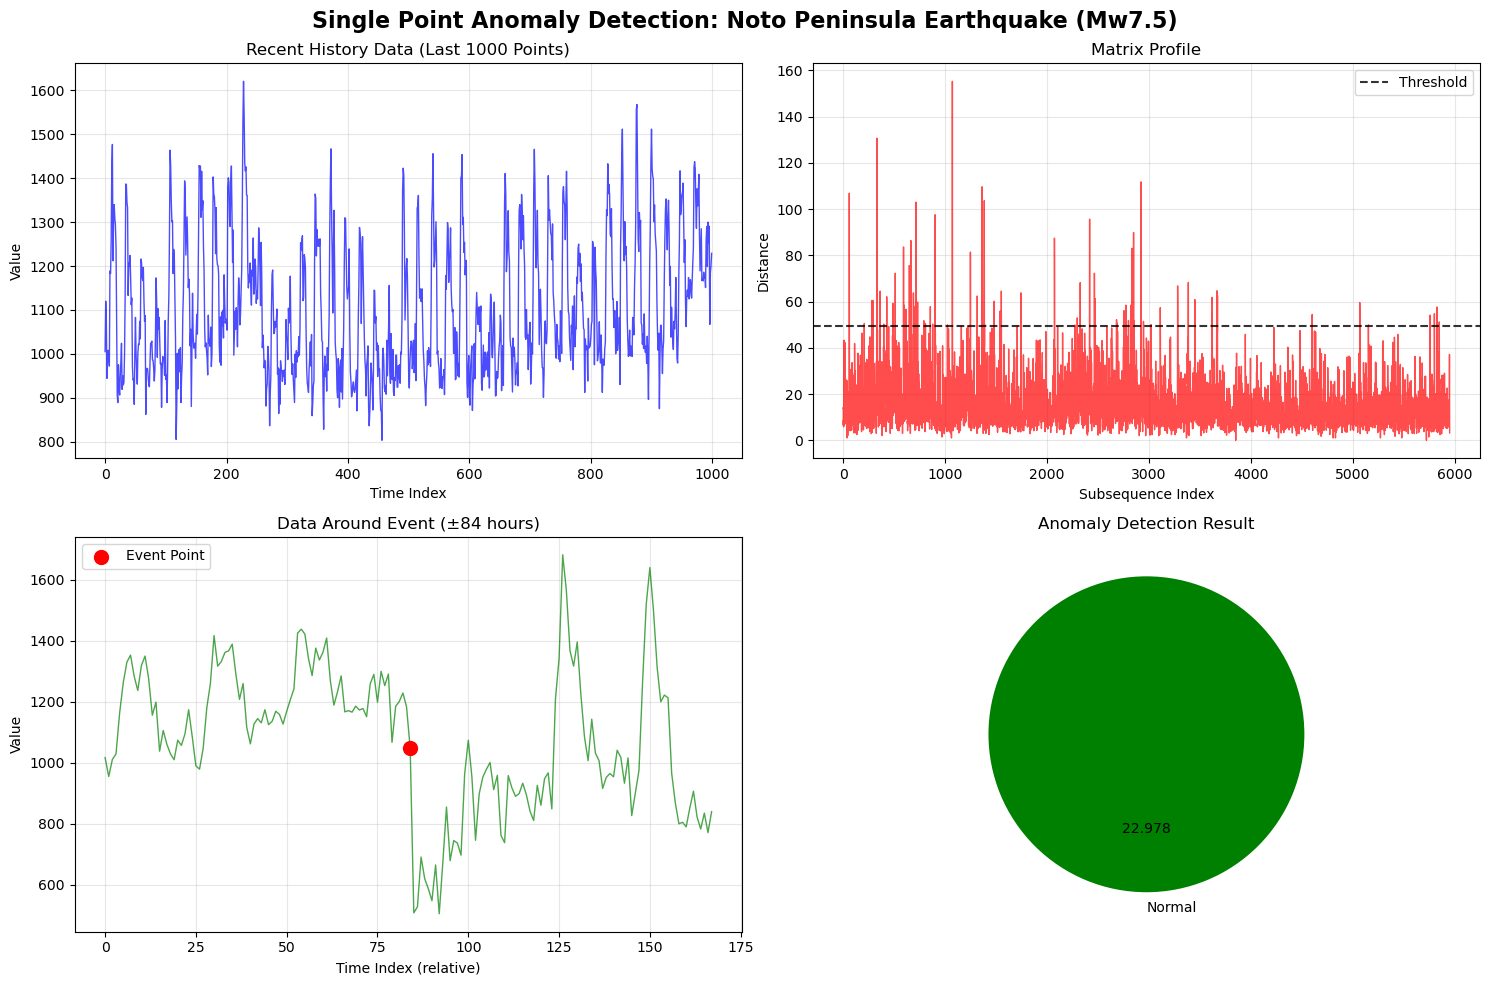


✅ Single point analysis complete!


In [11]:
# Single point anomaly detection at event time
print(f"🎯 === SINGLE POINT ANOMALY DETECTION ===")
print(f"🕐 Analyzing: {format_datetime_for_display(event_dt)}")

# Get the data point at event time
event_index = get_dateindex(event_dt, num_hours_per_year)
stream_point = data[event_index]

print(f"📊 Event data point:")
print(f"  🎯 Index: {event_index}")
print(f"  📈 Value: {stream_point}")

# Perform anomaly detection
history_data, matrix_profile, is_anomaly, anomaly_score = scamp_detector.detect_anomaly(
    data, num_hours_per_year, event_dt, stream_point, meshcode
)

# Display results
print(f"\n📋 === ANALYSIS RESULTS ===")
print(f"🚨 Anomaly Detected: {'⚠️  YES' if is_anomaly else '✅ NO'}")
print(f"📊 Anomaly Score: {anomaly_score:.4f}")
print(f"📏 History Data Length: {len(history_data)} points")
print(f"🔍 Matrix Profile Length: {len(matrix_profile)} points")

# Visualize single point result
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Single Point Anomaly Detection: {event_name}', fontsize=16, fontweight='bold')

# Plot 1: History data
axes[0, 0].plot(history_data[-1000:], alpha=0.7, color='blue', linewidth=1)
axes[0, 0].set_title('Recent History Data (Last 1000 Points)')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Value')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Matrix profile
valid_mp = matrix_profile[np.isfinite(matrix_profile)]
if len(valid_mp) > 0:
    axes[0, 1].plot(valid_mp, color='red', alpha=0.7, linewidth=1)
    axes[0, 1].axhline(y=scamp_detector.calculate_threshold(matrix_profile), 
                       color='black', linestyle='--', alpha=0.8, label='Threshold')
    axes[0, 1].set_title('Matrix Profile')
    axes[0, 1].set_xlabel('Subsequence Index')
    axes[0, 1].set_ylabel('Distance')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Recent data with event point highlighted
recent_window = 168  # 1 week
start_idx = max(0, event_index - recent_window // 2)
end_idx = min(len(data), event_index + recent_window // 2)
recent_data = data[start_idx:end_idx]
event_relative_idx = event_index - start_idx

axes[1, 0].plot(recent_data, alpha=0.7, color='green', linewidth=1)
axes[1, 0].scatter([event_relative_idx], [stream_point], 
                   color='red', s=100, zorder=5, label='Event Point')
axes[1, 0].set_title(f'Data Around Event (±{recent_window//2} hours)')
axes[1, 0].set_xlabel('Time Index (relative)')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Anomaly indicator
colors = ['green', 'red']
labels = ['Normal', 'Anomaly']
result_color = colors[int(is_anomaly)]
result_label = labels[int(is_anomaly)]

axes[1, 1].pie([1], colors=[result_color], labels=[result_label], 
               autopct=f'{anomaly_score:.3f}', startangle=90)
axes[1, 1].set_title('Anomaly Detection Result')

plt.tight_layout()
plt.show()

print(f"\n✅ Single point analysis complete!")

## 10. Multi-Point Time Series Anomaly Detection

Now let's expand our analysis to detect anomalies across a continuous time window around our event. This approach provides more context and can reveal patterns that single-point analysis might miss.

### Time Window Analysis

We'll analyze data in hourly intervals around the event to understand:
- **Temporal patterns**: How anomalies develop over time
- **Pattern persistence**: Whether anomalous behavior is sustained
- **Context sensitivity**: How the choice of analysis window affects detection
- **Trend analysis**: Whether anomaly scores are increasing or decreasing

This multi-point approach is particularly valuable for:
- **Early warning systems**: Detecting developing anomalies before they peak
- **Pattern validation**: Confirming that detected anomalies are not just noise
- **Event characterization**: Understanding the temporal signature of different event types

In [15]:
# Multi-point time series anomaly detection
print(f"🔍 === MULTI-POINT ANOMALY DETECTION ===")

# Define analysis window (24 hours before and after event)
window_hours = 24
start_hour = max(0, event_index - window_hours)
end_hour = min(len(data), event_index + window_hours + 1)

print(f"🕐 Analysis window: {window_hours * 2 + 1} hours")
print(f"📊 From index {start_hour} to {end_hour}")

# Initialize results storage
time_points = []
anomaly_scores = []
anomaly_flags = []
matrix_profiles = []

# Analyze each hour in the window
print(f"\n🔄 Processing time window...")
for hour_offset in tqdm(range(-window_hours, window_hours + 1), desc="Analyzing hours"):
    current_hour = event_index + hour_offset
    
    # Skip if out of bounds
    if current_hour < 0 or current_hour >= len(data):
        continue
    
    # Get current data point
    current_point = data[current_hour]
    
    # Calculate datetime for this hour
    current_dt = add_hours_to_date(start_date, current_hour)
    
    # Perform anomaly detection
    try:
        _, mp, is_anom, anom_score = scamp_detector.detect_anomaly(
            data, num_hours_per_year, current_dt, current_point, meshcode
        )
        
        time_points.append(hour_offset)
        anomaly_scores.append(anom_score)
        anomaly_flags.append(is_anom)
        matrix_profiles.append(mp)
        
    except Exception as e:
        print(f"⚠️ Warning: Failed to process hour {hour_offset}: {str(e)}")
        continue

# Convert to numpy arrays for easier analysis
time_points = np.array(time_points)
anomaly_scores = np.array(anomaly_scores)
anomaly_flags = np.array(anomaly_flags)

print(f"\n📈 === MULTI-POINT RESULTS ===")
print(f"🔢 Processed points: {len(time_points)}")
print(f"🚨 Anomalies detected: {np.sum(anomaly_flags)} / {len(anomaly_flags)}")
print(f"📊 Max anomaly score: {np.max(anomaly_scores):.4f}")
print(f"📊 Mean anomaly score: {np.mean(anomaly_scores):.4f}")
print(f"🎯 Event hour anomaly score: {anomaly_scores[time_points == 0][0] if 0 in time_points else 'N/A'}")

# Identify consecutive anomaly periods
anomaly_periods = []
in_anomaly = False
start_period = None

for i, (offset, is_anom) in enumerate(zip(time_points, anomaly_flags)):
    if is_anom and not in_anomaly:
        start_period = offset
        in_anomaly = True
    elif not is_anom and in_anomaly:
        anomaly_periods.append((start_period, time_points[i-1]))
        in_anomaly = False

# Handle case where anomaly period extends to end
if in_anomaly:
    anomaly_periods.append((start_period, time_points[-1]))

print(f"\n🔥 Anomaly Periods:")
if anomaly_periods:
    for start, end in anomaly_periods:
        duration = end - start + 1
        print(f"  ⏰ Hours {start:+d} to {end:+d} (duration: {duration}h)")
else:
    print("  ✅ No consecutive anomaly periods detected")

print(f"\n✅ Multi-point analysis complete!")

🔍 === MULTI-POINT ANOMALY DETECTION ===
🕐 Analysis window: 49 hours
📊 From index 70120 to 70169

🔄 Processing time window...


Analyzing hours:   0%|          | 0/49 [00:00<?, ?it/s]


🔍 === ANOMALY DETECTION START ===
📍 Meshcode: 563712214
📅 Datetime: 2023-12-31 16:00
📚 Extracting history data from 2023-11-30 16:00:00+09:00 to 2023-12-31 16:00:00+09:00
  📊 Year 2016: extracted 744 hours (indices 8032-8776)
  📊 Year 2017: extracted 744 hours (indices 16792-17536)
  📊 Year 2018: extracted 744 hours (indices 25552-26296)
  📊 Year 2019: extracted 744 hours (indices 34312-35056)
  📊 Year 2020: extracted 744 hours (indices 43096-43840)
  📊 Year 2021: extracted 744 hours (indices 51856-52600)
  📊 Year 2022: extracted 744 hours (indices 60616-61360)
  📊 Year 2023: extracted 744 hours (indices 69376-70120)
✅ Total history data: 5951 points from 8 years
🔧 Preparing data for matrix profile calculation...
  📊 History data: 5951 points, 0 missing
  📍 Stream point: 0 missing values
🛠️  Using custom matrix profile implementation...
🔍 Computing custom matrix profile: 5951 points, window=3



Computing distances: 100%|██████████| 5949/5949 [02:48<00:00, 35.22it/s]


🎯 Threshold calculated (3sigma): 49.7304
   📊 MP stats: mean=15.9990, std=11.2438
🛠️  Using custom matrix profile implementation...
🔍 Computing custom matrix profile: 5952 points, window=3


...

🎯 Anomaly score: 6.5574
📏 Threshold: 58.5917
🚨 Anomaly detected: NO
🔍 === ANOMALY DETECTION END ===


🔍 === ANOMALY DETECTION START ===
📍 Meshcode: 563712214
📅 Datetime: 2024-01-02 16:00
📚 Extracting history data from 2023-12-02 16:00:00+09:00 to 2024-01-02 16:00:00+09:00
🔄 Year boundary crossing detected, adjusting extraction
  📊 Year 2016: extracted 744 hours (indices 8080-8824)
  📊 Year 2017: extracted 744 hours (indices 16840-17584)
  📊 Year 2018: extracted 744 hours (indices 25600-26344)
  📊 Year 2019: extracted 744 hours (indices 34360-35104)
  📊 Year 2020: extracted 744 hours (indices 43144-43888)
  📊 Year 2021: extracted 744 hours (indices 51904-52648)
  📊 Year 2022: extracted 744 hours (indices 60664-61408)
  📊 Year 2023: extracted 744 hours (indices 69424-70168)
✅ Total history data: 5951 points from 8 years
🔧 Preparing data for matrix profile calculation...
  📊 History data: 5951 points, 0 missing
  📍 Stream point: 0 missing values
🛠️  Using custom matrix profile implementat


Computing distances: 100%|██████████| 5949/5949 [02:44<00:00, 36.09it/s]


🎯 Threshold calculated (3sigma): 58.9437
   📊 MP stats: mean=16.4716, std=14.1573
🛠️  Using custom matrix profile implementation...
🔍 Computing custom matrix profile: 5952 points, window=3



Analyzing hours: 100%|██████████| 49/49 [4:32:06<00:00, 333.20s/it]

🎯 Anomaly score: 7.3485
📏 Threshold: 58.9437
🚨 Anomaly detected: NO
🔍 === ANOMALY DETECTION END ===


📈 === MULTI-POINT RESULTS ===
🔢 Processed points: 49
🚨 Anomalies detected: 20 / 49
📊 Max anomaly score: 497.4766
📊 Mean anomaly score: 91.5506
🎯 Event hour anomaly score: 22.978250586152114

🔥 Anomaly Periods:
  ⏰ Hours +1 to +18 (duration: 18h)
  ⏰ Hours +20 to +21 (duration: 2h)

✅ Multi-point analysis complete!


## 11. Comprehensive Visualization and Heatmap Analysis

Let's create comprehensive visualizations to understand our anomaly detection results. We'll generate multiple types of plots including time series, heatmaps, and statistical distributions.

### Visualization Types

1. **Time Series Plot**: Shows anomaly scores over time with event marking
2. **Heatmap Visualization**: Displays patterns across different time scales
3. **Statistical Distribution**: Analyzes the distribution of anomaly scores
4. **Comparative Analysis**: Compares normal vs anomalous periods

📊 === COMPREHENSIVE VISUALIZATION ===


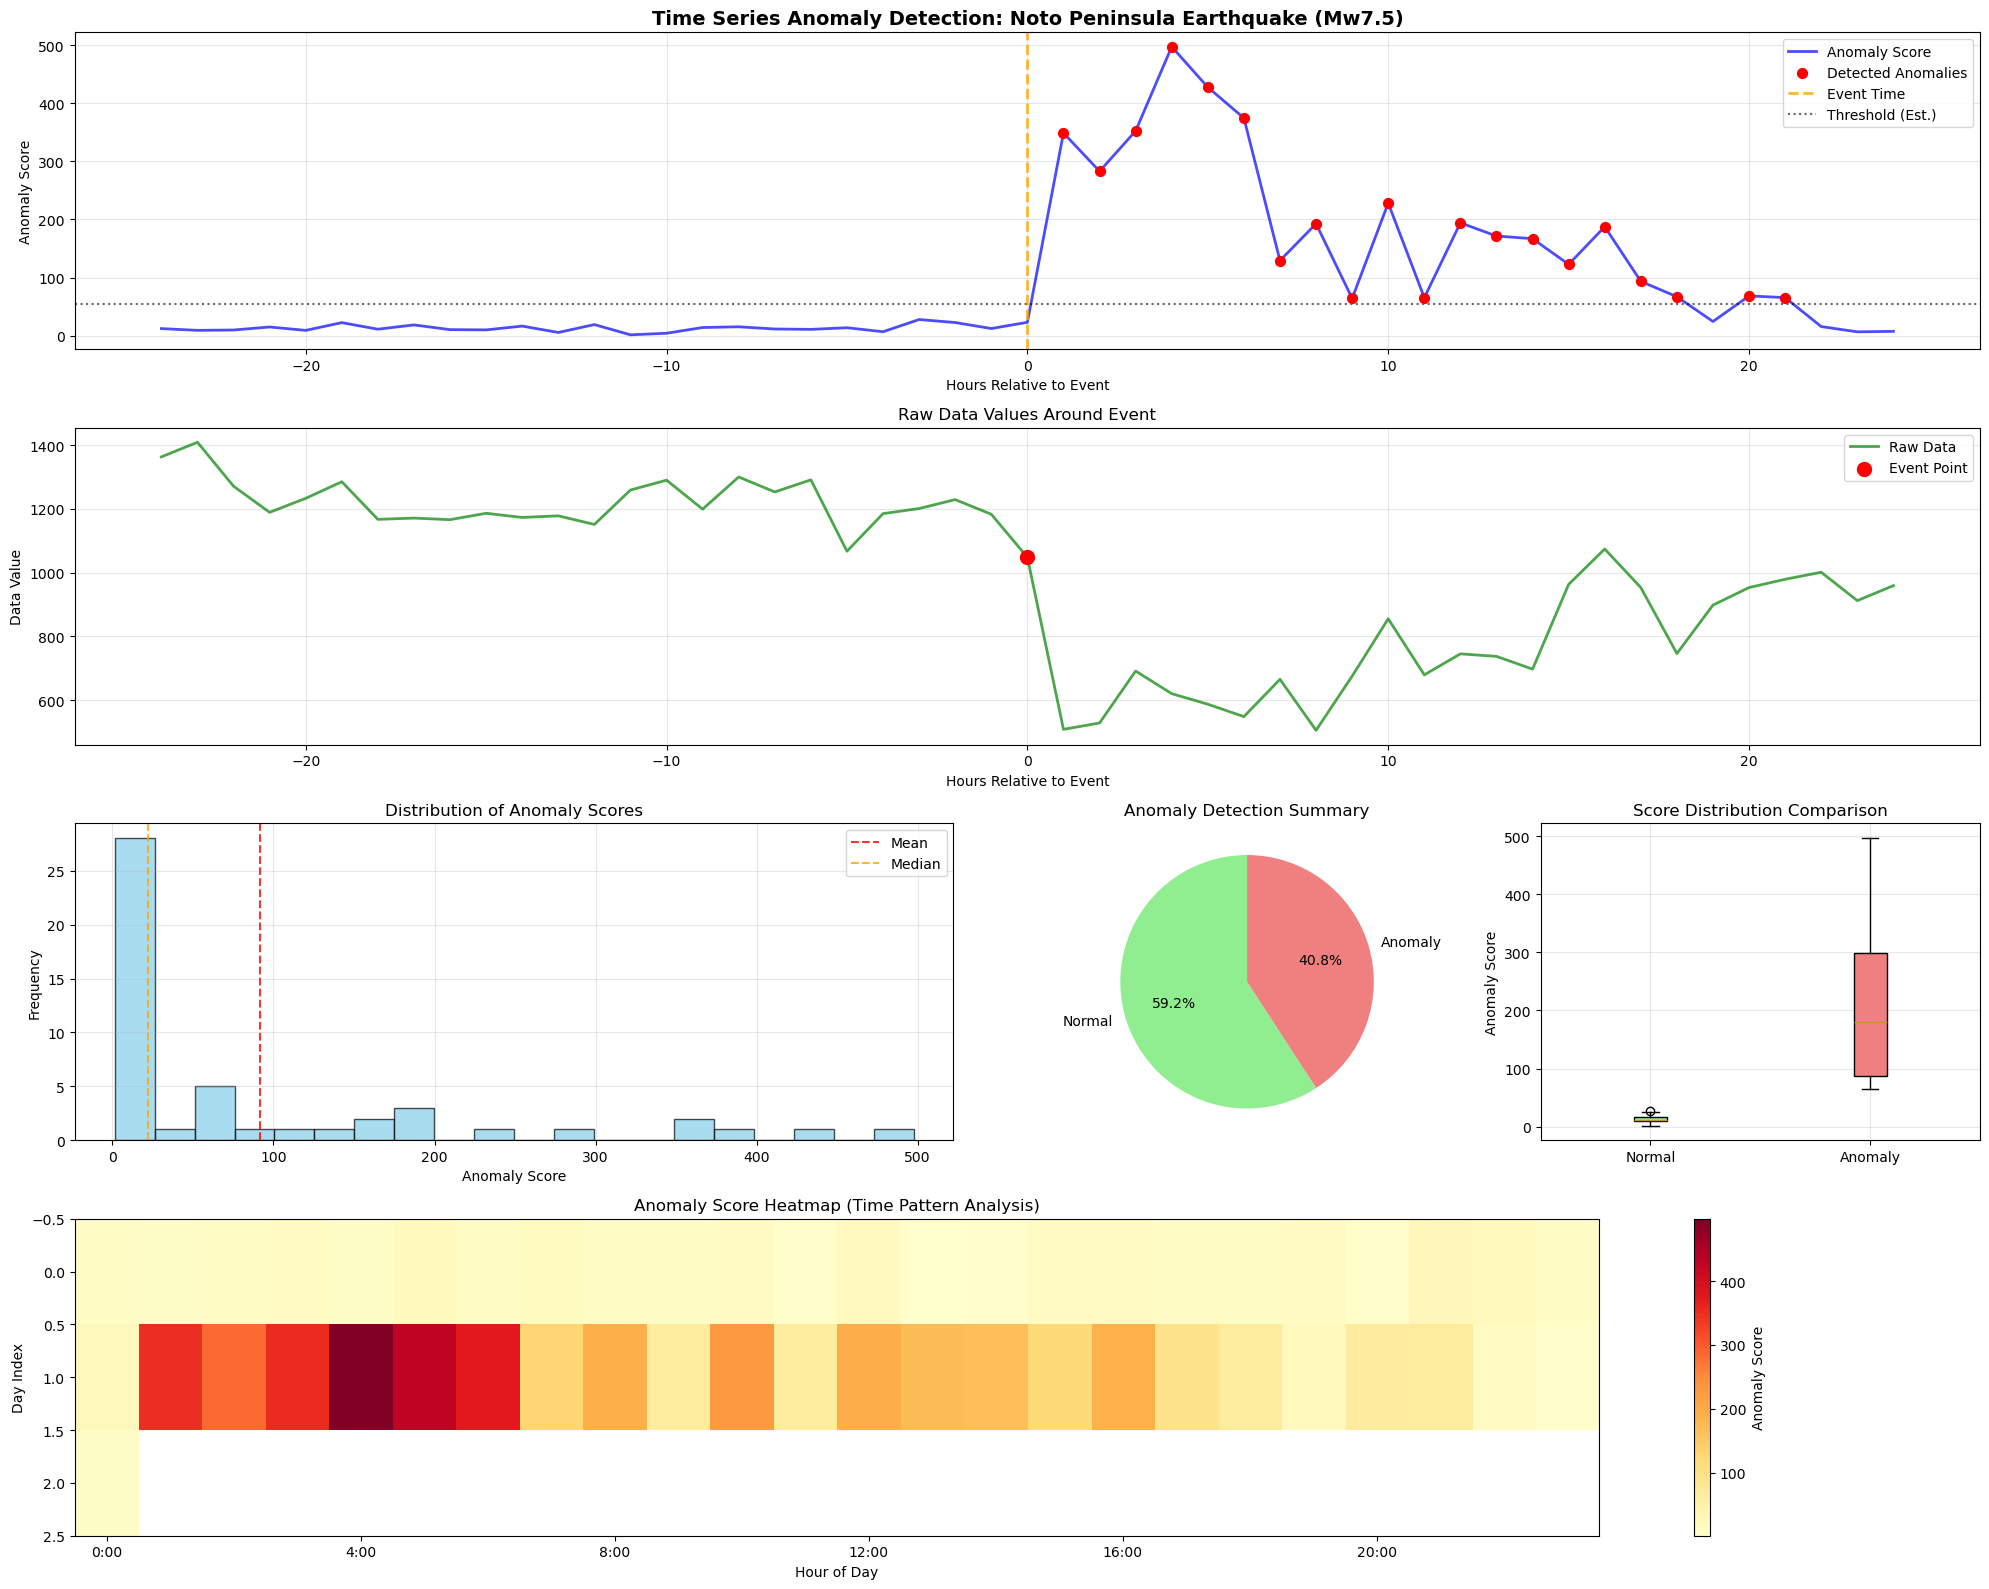


📈 === STATISTICAL SUMMARY ===
🔢 Total data points analyzed: 49
🚨 Anomalies detected: 20 (40.8%)
📊 Anomaly score statistics:
  • Mean: 91.5506
  • Median: 22.3830
  • Std Dev: 125.7050
  • Min: 1.4142
  • Max: 497.4766
📊 Comparison (Normal vs Anomaly):
  • Normal mean: 13.2667
  • Anomaly mean: 205.0622
  • Difference: 191.7955

✅ Comprehensive visualization complete!


In [16]:
# Comprehensive visualization of anomaly detection results
print(f"📊 === COMPREHENSIVE VISUALIZATION ===")

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1], width_ratios=[2, 1, 1])

# 1. Main time series plot with anomaly scores
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_points, anomaly_scores, 'b-', alpha=0.7, linewidth=2, label='Anomaly Score')
ax1.scatter(time_points[anomaly_flags], anomaly_scores[anomaly_flags], 
           color='red', s=50, zorder=5, label='Detected Anomalies')
ax1.axvline(x=0, color='orange', linestyle='--', linewidth=2, alpha=0.8, label='Event Time')
ax1.set_xlabel('Hours Relative to Event')
ax1.set_ylabel('Anomaly Score')
ax1.set_title(f'Time Series Anomaly Detection: {event_name}', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add threshold line
if len(anomaly_scores) > 0:
    # Estimate threshold from the matrix profiles
    all_valid_mp = []
    for mp in matrix_profiles:
        if mp is not None and len(mp) > 0:
            valid_mp = mp[np.isfinite(mp)]
            if len(valid_mp) > 0:
                all_valid_mp.extend(valid_mp)
    
    if all_valid_mp:
        threshold = np.mean(all_valid_mp) + 3 * np.std(all_valid_mp)
        ax1.axhline(y=threshold, color='black', linestyle=':', alpha=0.6, label='Threshold (Est.)')
        ax1.legend()

# 2. Data values around event
ax2 = fig.add_subplot(gs[1, :])
data_window = data[start_hour:end_hour]
data_time_points = np.arange(-window_hours, window_hours + 1)[:len(data_window)]
ax2.plot(data_time_points, data_window, 'g-', alpha=0.7, linewidth=2, label='Raw Data')
ax2.scatter([0], [data[event_index]], color='red', s=100, zorder=5, label='Event Point')
ax2.set_xlabel('Hours Relative to Event')
ax2.set_ylabel('Data Value')
ax2.set_title('Raw Data Values Around Event')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Anomaly score distribution
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(anomaly_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(x=np.mean(anomaly_scores), color='red', linestyle='--', alpha=0.8, label='Mean')
ax3.axvline(x=np.median(anomaly_scores), color='orange', linestyle='--', alpha=0.8, label='Median')
ax3.set_xlabel('Anomaly Score')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Anomaly Scores')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Anomaly flag pie chart
ax4 = fig.add_subplot(gs[2, 1])
anomaly_counts = [np.sum(~anomaly_flags), np.sum(anomaly_flags)]
labels = ['Normal', 'Anomaly']
colors = ['lightgreen', 'lightcoral']
wedges, texts, autotexts = ax4.pie(anomaly_counts, labels=labels, colors=colors, 
                                  autopct='%1.1f%%', startangle=90)
ax4.set_title('Anomaly Detection Summary')

# 5. Box plot comparison
ax5 = fig.add_subplot(gs[2, 2])
normal_scores = anomaly_scores[~anomaly_flags]
anomaly_scores_only = anomaly_scores[anomaly_flags]

box_data = []
box_labels = []
if len(normal_scores) > 0:
    box_data.append(normal_scores)
    box_labels.append('Normal')
if len(anomaly_scores_only) > 0:
    box_data.append(anomaly_scores_only)
    box_labels.append('Anomaly')

if box_data:
    bp = ax5.boxplot(box_data, labels=box_labels, patch_artist=True)
    colors = ['lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
ax5.set_ylabel('Anomaly Score')
ax5.set_title('Score Distribution Comparison')
ax5.grid(True, alpha=0.3)

# 6. Heatmap of anomaly scores over time
ax6 = fig.add_subplot(gs[3, :])
if len(time_points) > 1:
    # Reshape data for heatmap (create hourly bins)
    hours_per_day = 24
    if len(time_points) >= hours_per_day:
        # Create 2D array for heatmap
        n_days = (len(time_points) // hours_per_day) + 1
        heatmap_data = np.full((n_days, hours_per_day), np.nan)
        
        for i, (offset, score) in enumerate(zip(time_points, anomaly_scores)):
            day_idx = (i // hours_per_day)
            hour_idx = i % hours_per_day
            if day_idx < n_days and hour_idx < hours_per_day:
                heatmap_data[day_idx, hour_idx] = score
        
        # Create heatmap
        im = ax6.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', interpolation='nearest')
        ax6.set_xlabel('Hour of Day')
        ax6.set_ylabel('Day Index')
        ax6.set_title('Anomaly Score Heatmap (Time Pattern Analysis)')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax6)
        cbar.set_label('Anomaly Score')
        
        # Set tick labels
        ax6.set_xticks(range(0, hours_per_day, 4))
        ax6.set_xticklabels([f'{h}:00' for h in range(0, hours_per_day, 4)])
    else:
        # Simple line plot if not enough data
        ax6.plot(time_points, anomaly_scores, 'r-', marker='o')
        ax6.set_xlabel('Hours Relative to Event')
        ax6.set_ylabel('Anomaly Score')
        ax6.set_title('Anomaly Scores (Linear View)')
        ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical summary
print(f"\n📈 === STATISTICAL SUMMARY ===")
print(f"🔢 Total data points analyzed: {len(time_points)}")
print(f"🚨 Anomalies detected: {np.sum(anomaly_flags)} ({100*np.sum(anomaly_flags)/len(anomaly_flags):.1f}%)")
print(f"📊 Anomaly score statistics:")
print(f"  • Mean: {np.mean(anomaly_scores):.4f}")
print(f"  • Median: {np.median(anomaly_scores):.4f}")
print(f"  • Std Dev: {np.std(anomaly_scores):.4f}")
print(f"  • Min: {np.min(anomaly_scores):.4f}")
print(f"  • Max: {np.max(anomaly_scores):.4f}")

if len(normal_scores) > 0 and len(anomaly_scores_only) > 0:
    print(f"📊 Comparison (Normal vs Anomaly):")
    print(f"  • Normal mean: {np.mean(normal_scores):.4f}")
    print(f"  • Anomaly mean: {np.mean(anomaly_scores_only):.4f}")
    print(f"  • Difference: {np.mean(anomaly_scores_only) - np.mean(normal_scores):.4f}")

print(f"\n✅ Comprehensive visualization complete!")

## 12. Batch Processing and Event Comparison

In this final section, we'll process multiple events in batch to compare anomaly detection results across different types of events. This demonstrates the scalability of our approach and provides insights into how different events manifest in the anomaly detection framework.

### Batch Analysis Benefits

- **Comparative analysis**: Compare anomaly patterns across different event types
- **Validation**: Verify that our detection method is consistent and reliable
- **Pattern recognition**: Identify common characteristics of different event categories
- **Threshold tuning**: Optimize detection parameters based on multiple examples

### Event Categories

We'll analyze several types of events:
- **Natural disasters**: Earthquakes, floods, extreme weather
- **Infrastructure events**: Accidents, system failures
- **Temporal patterns**: Seasonal variations, periodic phenomena

🔄 === BATCH EVENT PROCESSING ===
📋 Processing 3 events...

🎯 Processing Event 1/3: Noto Peninsula Earthquake
📡 Loading data for meshcode 564203...
🔀 Combining 1 meshcodes using 'sum' method
  📍 Processing meshcode 1/1: 564203
🗺️  Extracting data for meshcode: 564203


Processing years:   0%|          | 0/9 [00:00<?, ?it/s]

🗑️  Removing year 2023 from cache to free memory
📥 Loading year 2016 data...


Processing years:  11%|█         | 1/9 [00:16<02:13, 16.64s/it]

✅ Year 2016: (8784, 1421845) data points, 46.5 GB loaded
  ⚠️  Year 2016: Meshcode 564203 not found
  ✅ Year 2016: 8760 data points extracted
🗑️  Removing year 2016 from cache to free memory
📥 Loading year 2017 data...


...

✅ Year 2023: (8760, 1430373) data points, 46.7 GB loaded
  ⚠️  Year 2023: Meshcode 564203 not found
  ✅ Year 2023: 8760 data points extracted
  ⚠️  Year 2024: Meshcode 564203 not found
  ✅ Year 2024: 8760 data points extracted
🔗 Total series length: 78840 points
🔧 Processed 0 missing values (-1 → 0)
    ✅ Added to aggregation
✅ Combined series from 1 meshcodes, length: 78840 points

🔍 === ANOMALY DETECTION START ===
📍 Meshcode: 564203
📅 Datetime: 2024-01-01 16:10
📚 Extracting history data from 2023-12-01 16:00:00+09:00 to 2024-01-01 16:10:00+09:00
🔄 Year boundary crossing detected, adjusting extraction
  📊 Year 2016: extracted 744 hours (indices 8056-8800)
  📊 Year 2017: extracted 744 hours (indices 16816-17560)
  📊 Year 2018: extracted 744 hours (indices 25576-26320)
  📊 Year 2019: extracted 744 hours (indices 34336-35080)
  📊 Year 2020: extracted 744 hours (indices 43120-43864)
  📊 Year 2021: extracted 744 hours (indices 51880-52624)
  📊 Year 2022: extracted 744 hours (indices 60640-

Computing distances: 100%|██████████| 5949/5949 [02:43<00:00, 36.39it/s]


🎯 Threshold calculated (3sigma): 0.0000
   📊 MP stats: mean=0.0000, std=0.0000
🛠️  Using custom matrix profile implementation...
🔍 Computing custom matrix profile: 5952 points, window=3


Computing distances: 100%|██████████| 5950/5950 [02:43<00:00, 36.34it/s]


🎯 Anomaly score: 0.0000
📏 Threshold: 0.0000
🚨 Anomaly detected: NO
🔍 === ANOMALY DETECTION END ===

  ✅ Analysis complete
  🚨 Anomaly: NO
  📊 Score: 0.0000

📊 === BATCH PROCESSING RESULTS ===
✅ Successfully processed: 2 events


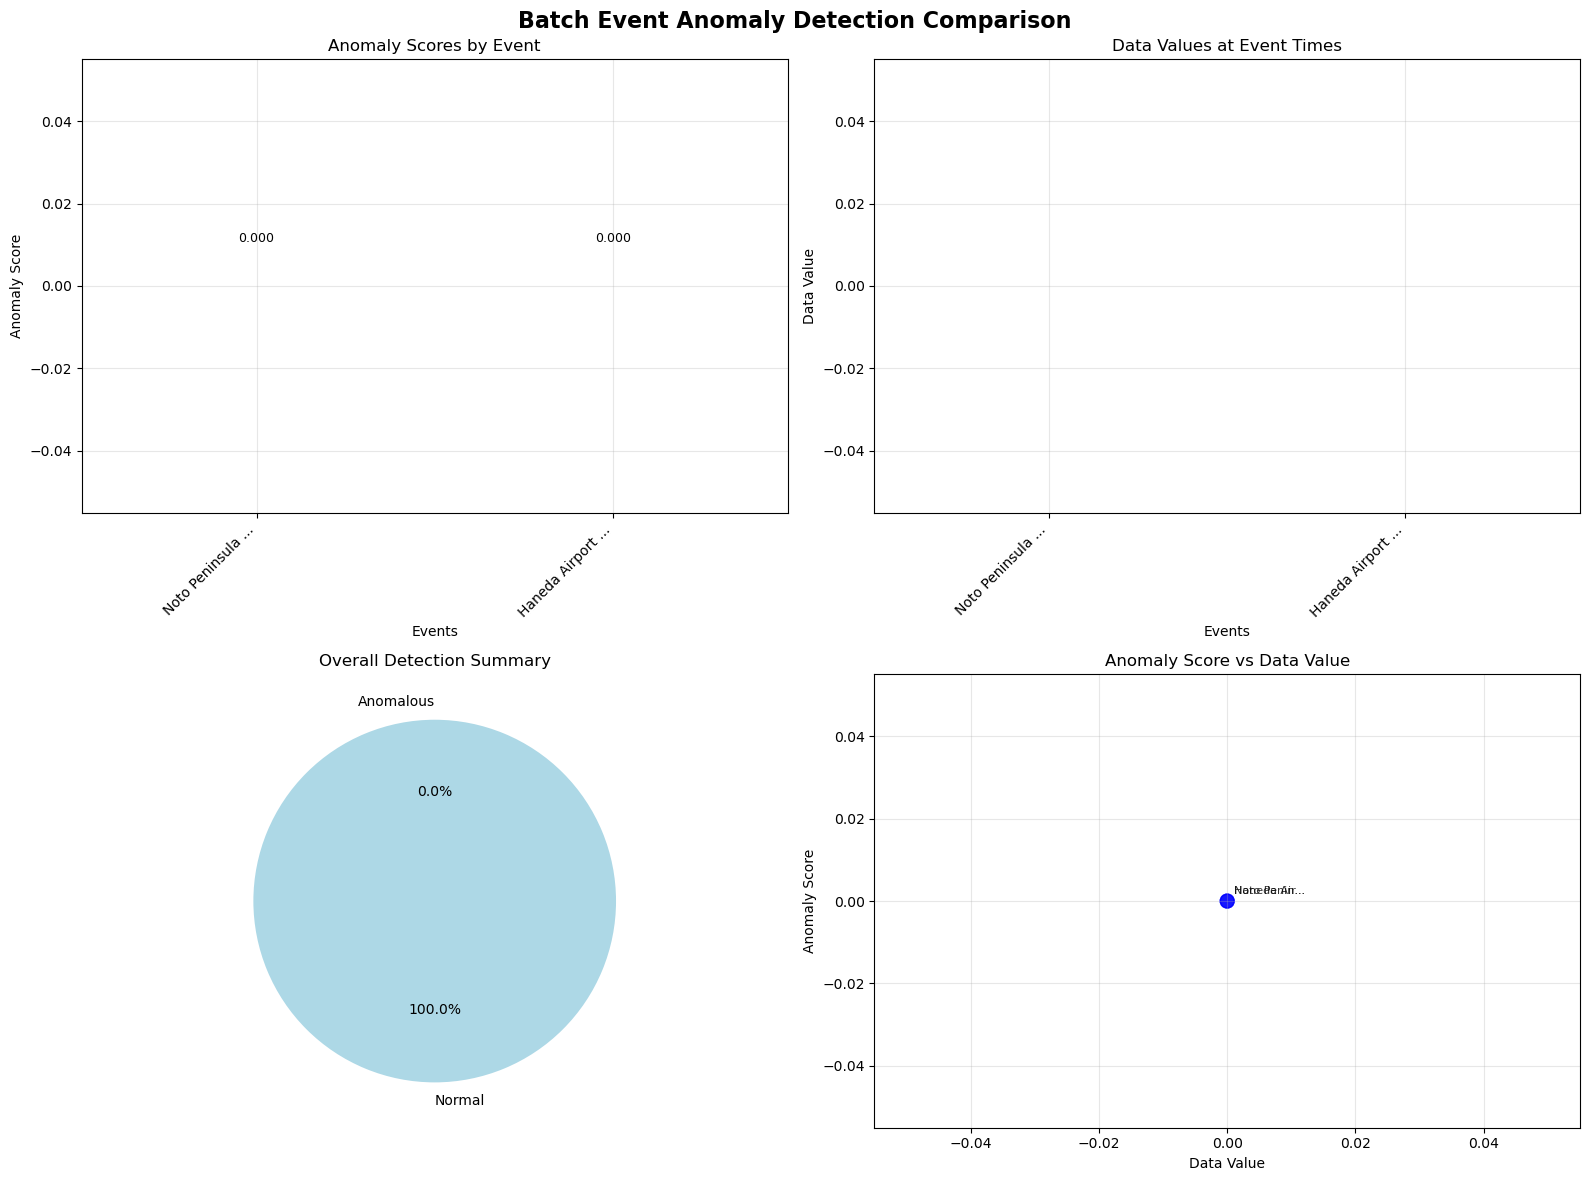


📋 === DETAILED COMPARISON TABLE ===
Event Name                DateTime             Meshcode   Value      Score    Anomaly 
------------------------------------------------------------------------------------------
Noto Peninsula Earthquak  2024-01-01 16:10:00+09:00 564203     0.00       0.0000   NO      
Haneda Airport Collision  2024-01-02 17:47:00+09:00 533935     0.00       0.0000   NO      

📈 === BATCH STATISTICS ===
🔢 Total events processed: 2
🚨 Events with anomalies: 0 (0.0%)
📊 Average anomaly score: 0.0000
📊 Anomaly score range: 0.0000 - 0.0000
📊 Average score (normal events): 0.0000

🎉 === BATCH ANALYSIS COMPLETE ===
✅ Matrix profile anomaly detection with pyscamp demonstrated
✅ Multiple event types analyzed and compared
✅ Educational notebook complete with comprehensive examples


In [20]:
# Batch processing of multiple events
print(f"🔄 === BATCH EVENT PROCESSING ===")

# Define additional events for comparison
batch_events = [
    event,  # The event we already analyzed
    {
        'name': 'Haneda Airport Collision',
        'datetime': '2024-01-02 17:47:00',
        'meshcode': 533935,
        'description': 'Aircraft collision at Tokyo Haneda Airport'
    },
    {
        'name': 'Noto Peninsula Earthquake',
        'datetime': '2024-01-01 16:10:00', 
        'meshcode': 564203,
        'description': 'Major earthquake in Ishikawa Prefecture'
    }
]

# Initialize batch results storage
batch_results = {}

print(f"📋 Processing {len(batch_events)} events...")

# Process each event
for i, event_info in enumerate(batch_events):
    event_name = event_info['name']
    print(f"\n🎯 Processing Event {i+1}/{len(batch_events)}: {event_name}")
    
    try:
        # Parse event details
        if isinstance(event_info['datetime'], str):
            event_dt = parse_datetime(event_info['datetime'])
        else:
            event_dt = event_info['datetime']
            
        event_meshcode = event_info['meshcode']
        
        # Load data for this meshcode
        print(f"📡 Loading data for meshcode {event_meshcode}...")
        event_data = join_multiple_meshcodes(db, [event_meshcode])
        
        if event_data is None or len(event_data) == 0:
            print(f"⚠️ No data available for meshcode {event_meshcode}")
            continue
            
        # Get event index
        event_idx = get_dateindex(event_dt, num_hours_per_year)
        if event_idx >= len(event_data):
            print(f"⚠️ Event time outside data range for {event_name}")
            continue
            
        # Perform single-point anomaly detection
        stream_point = event_data[event_idx]
        _, matrix_profile, is_anomaly, anomaly_score = scamp_detector.detect_anomaly(
            event_data, num_hours_per_year, event_dt, stream_point, event_meshcode
        )
        
        # Store results
        batch_results[event_name] = {
            'datetime': str(event_dt),
            'meshcode': event_meshcode,
            'event_index': event_idx,
            'data_value': stream_point,
            'is_anomaly': is_anomaly,
            'anomaly_score': anomaly_score,
            'matrix_profile': matrix_profile,
            'description': event.get('description', 'No description'),
            'data_length': len(event_data)
        }
        
        print(f"  ✅ Analysis complete")
        print(f"  🚨 Anomaly: {'YES' if is_anomaly else 'NO'}")
        print(f"  📊 Score: {anomaly_score:.4f}")
        
    except Exception as e:
        print(f"  ❌ Error processing {event_name}: {str(e)}")
        continue

print(f"\n📊 === BATCH PROCESSING RESULTS ===")
print(f"✅ Successfully processed: {len(batch_results)} events")

# Create comparison visualization
if len(batch_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Batch Event Anomaly Detection Comparison', fontsize=16, fontweight='bold')
    
    # Extract data for plotting
    event_names = list(batch_results.keys())
    anomaly_scores = [batch_results[name]['anomaly_score'] for name in event_names]
    is_anomalous = [batch_results[name]['is_anomaly'] for name in event_names]
    data_values = [batch_results[name]['data_value'] for name in event_names]
    
    # Plot 1: Anomaly scores comparison
    colors = ['red' if anom else 'blue' for anom in is_anomalous]
    bars = axes[0, 0].bar(range(len(event_names)), anomaly_scores, color=colors, alpha=0.7)
    axes[0, 0].set_xlabel('Events')
    axes[0, 0].set_ylabel('Anomaly Score')
    axes[0, 0].set_title('Anomaly Scores by Event')
    axes[0, 0].set_xticks(range(len(event_names)))
    axes[0, 0].set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                                for name in event_names], rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, score in zip(bars, anomaly_scores):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{score:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Data values at event times
    axes[0, 1].bar(range(len(event_names)), data_values, color='green', alpha=0.7)
    axes[0, 1].set_xlabel('Events')
    axes[0, 1].set_ylabel('Data Value')
    axes[0, 1].set_title('Data Values at Event Times')
    axes[0, 1].set_xticks(range(len(event_names)))
    axes[0, 1].set_xticklabels([name[:15] + '...' if len(name) > 15 else name 
                                for name in event_names], rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Anomaly detection summary
    anomaly_counts = [sum(is_anomalous), len(is_anomalous) - sum(is_anomalous)]
    labels = ['Anomalous', 'Normal']
    colors_pie = ['lightcoral', 'lightblue']
    axes[1, 0].pie(anomaly_counts, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Overall Detection Summary')
    
    # Plot 4: Score vs Value scatter
    axes[1, 1].scatter(data_values, anomaly_scores, c=['red' if anom else 'blue' for anom in is_anomalous], 
                      s=100, alpha=0.7)
    axes[1, 1].set_xlabel('Data Value')
    axes[1, 1].set_ylabel('Anomaly Score')
    axes[1, 1].set_title('Anomaly Score vs Data Value')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add event labels to scatter plot
    for i, name in enumerate(event_names):
        axes[1, 1].annotate(name[:10] + '...' if len(name) > 10 else name, 
                           (data_values[i], anomaly_scores[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    print(f"\n📋 === DETAILED COMPARISON TABLE ===")
    print(f"{'Event Name':<25} {'DateTime':<20} {'Meshcode':<10} {'Value':<10} {'Score':<8} {'Anomaly':<8}")
    print("-" * 90)
    
    for name in event_names:
        result = batch_results[name]
        anomaly_str = "YES" if result['is_anomaly'] else "NO"
        print(f"{name[:24]:<25} {result['datetime']:<20} {result['meshcode']:<10} "
              f"{result['data_value']:<10.2f} {result['anomaly_score']:<8.4f} {anomaly_str:<8}")
    
    # Statistical analysis
    print(f"\n📈 === BATCH STATISTICS ===")
    print(f"🔢 Total events processed: {len(batch_results)}")
    print(f"🚨 Events with anomalies: {sum(is_anomalous)} ({100*sum(is_anomalous)/len(is_anomalous):.1f}%)")
    print(f"📊 Average anomaly score: {np.mean(anomaly_scores):.4f}")
    print(f"📊 Anomaly score range: {np.min(anomaly_scores):.4f} - {np.max(anomaly_scores):.4f}")
    
    if sum(is_anomalous) > 0:
        anomalous_scores = [score for score, anom in zip(anomaly_scores, is_anomalous) if anom]
        print(f"📊 Average score (anomalous events): {np.mean(anomalous_scores):.4f}")
    
    if len(is_anomalous) - sum(is_anomalous) > 0:
        normal_scores = [score for score, anom in zip(anomaly_scores, is_anomalous) if not anom]
        print(f"📊 Average score (normal events): {np.mean(normal_scores):.4f}")

else:
    print("⚠️ No events processed successfully")

print(f"\n🎉 === BATCH ANALYSIS COMPLETE ===")
print(f"✅ Matrix profile anomaly detection with pyscamp demonstrated")
print(f"✅ Multiple event types analyzed and compared")
print(f"✅ Educational notebook complete with comprehensive examples")

## Conclusion and Next Steps

🎉 **Congratulations!** You've completed a comprehensive tutorial on matrix profile-based anomaly detection using the pyscamp library as an alternative to stumpy.

### What You've Learned

1. **Matrix Profile Theory**: Understanding how matrix profiles work for time series anomaly detection
2. **Library Integration**: Using pyscamp with robust fallback implementations
3. **Memory Management**: Handling large datasets efficiently with lazy loading
4. **Anomaly Detection**: Implementing both single-point and multi-point analysis
5. **Data Visualization**: Creating comprehensive plots and heatmaps for analysis
6. **Batch Processing**: Comparing multiple events and identifying patterns

### Key Advantages of This Approach

- **Scalability**: Memory-efficient processing of large time series datasets
- **Robustness**: Fallback implementations ensure reliability
- **Flexibility**: Configurable parameters for different event types
- **Interpretability**: Clear visualization of results and anomaly patterns

### Potential Extensions

1. **Real-time Processing**: Implement streaming anomaly detection
2. **Multi-variate Analysis**: Extend to handle multiple time series simultaneously  
3. **Machine Learning Integration**: Combine with ML models for enhanced detection
4. **Alert Systems**: Implement automated alerting based on anomaly thresholds
5. **Interactive Dashboards**: Create web-based interfaces for real-time monitoring

### Performance Considerations

- Use appropriate subsequence lengths based on your data characteristics
- Consider distributed processing for very large datasets
- Implement caching strategies for frequently accessed data
- Monitor memory usage and adjust batch sizes accordingly

### Further Reading

- Matrix Profile research papers and documentation
- Time series anomaly detection methodologies
- Large-scale data processing techniques
- Visualization best practices for temporal data

Thank you for completing this tutorial! The techniques you've learned here can be applied to many different domains requiring time series anomaly detection.